# 1) Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from collections import Counter

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


Carregando Arquivo e transformando colunas

In [ ]:
#Carregar o CSV
arquivo_csv = 'dataset_classificacao_vogal_A_normal.csv'
df = pd.read_csv(arquivo_csv)

print(f"📊 Dataset Original: {df.shape[0]} linhas, {df.shape[1]} colunas.")

# Remover colunas que não são características acústicas nem clínicas
colunas_inuteis = ['Nome_Arquivo', 'Patologia_Original', 'ID_Gravacao', 'ID_Paciente']
df_limpo = df.drop(columns=colunas_inuteis, errors='ignore')

# Remover valores vazios (NaN)
df_limpo = df_limpo.dropna()

# Arredondando idade
if 'Idade' in df_limpo.columns:
    df_limpo['Idade'] = df_limpo['Idade'].round().astype(int)

# Encoding
le = LabelEncoder()
if 'Sexo' in df_limpo.columns:
    df_limpo['Sexo'] = le.fit_transform(df_limpo['Sexo'])
    print(f"🔄 Sexo codificado: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n📋 Amostra dos dados limpos:")
display(df_limpo.head())

📊 Dataset Original: 1464 linhas, 16 colunas.
🔄 Sexo codificado: {'F': np.int64(0), 'M': np.int64(1)}

📋 Amostra dos dados limpos:


,Grupo_Alvo,Idade,Sexo,f0_mean,f0_std,f0_min,f0_max,jitter_local,jitter_rap,shimmer_local,shimmer_db,hnr
0,2,59,1,169.329504,30.270889,79.097319,248.025140,1.452848,0.731192,4.150929,0.471505,20.472904
1,2,63,1,79.493672,2.073100,75.199094,89.197652,1.967100,1.100514,8.656242,0.843980,9.635692
2,2,58,1,170.892557,2.404023,164.043981,175.938641,0.998545,0.576863,6.010533,0.549174,12.977379
3,2,58,1,210.788520,3.487506,204.760310,220.037832,1.275788,0.795547,10.060927,0.885818,14.845637
4,2,43,1,167.619778,6.586444,153.292094,179.840444,2.822467,1.676677,15.635894,1.409448,6.686018


3) Split Treino e Teste

In [ ]:
# Separar X e Y
X = df_limpo.drop('Grupo_Alvo', axis=1)
y = df_limpo['Grupo_Alvo']

# Dividir em Treino e Teste
# stratify=y: garante que a proporção de Câncer seja mantida igual nos dois grupos.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"🔹 Treino: {X_train.shape[0]} amostras")
print(f"🔸 Teste:  {X_test.shape[0]} amostras")

🔹 Treino: 1170 amostras
🔸 Teste:  293 amostras


4) Scalling

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter de volta para DataFrame para não perder os nomes das colunas
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✅ Dados normalizados (Média 0, Desvio Padrão 1).")
display(X_train_final.head(3))

✅ Dados normalizados (Média 0, Desvio Padrão 1).


,Idade,Sexo,f0_mean,f0_std,f0_min,f0_max,jitter_local,jitter_rap,shimmer_local,shimmer_db,hnr
0,0.808819,1.106497,0.487356,-0.257337,0.612354,0.352827,0.370862,0.420052,0.599291,0.571302,-0.917575
1,-1.076277,-0.903753,0.602598,-0.302590,0.703274,0.429742,-0.439149,-0.407126,-0.673611,-0.670217,0.326474
2,0.861183,-0.903753,0.517771,-0.211258,0.642124,0.399921,-0.509813,-0.510849,-0.518711,-0.525938,1.146502


5) SMOTE Ballancing

DISTRIBUIÇÃO ANTES DO BALANCEAMENTO:
Counter({1: 567, 0: 549, 2: 54})

DISTRIBUIÇÃO DEPOIS DO SMOTE:
Counter({1: 567, 0: 567, 2: 567})


C:\Users\Administrador\AppData\Local\Temp\ipykernel_26756\45856029.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')
C:\Users\Administrador\AppData\Local\Temp\ipykernel_26756\45856029.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_bal, palette='viridis')


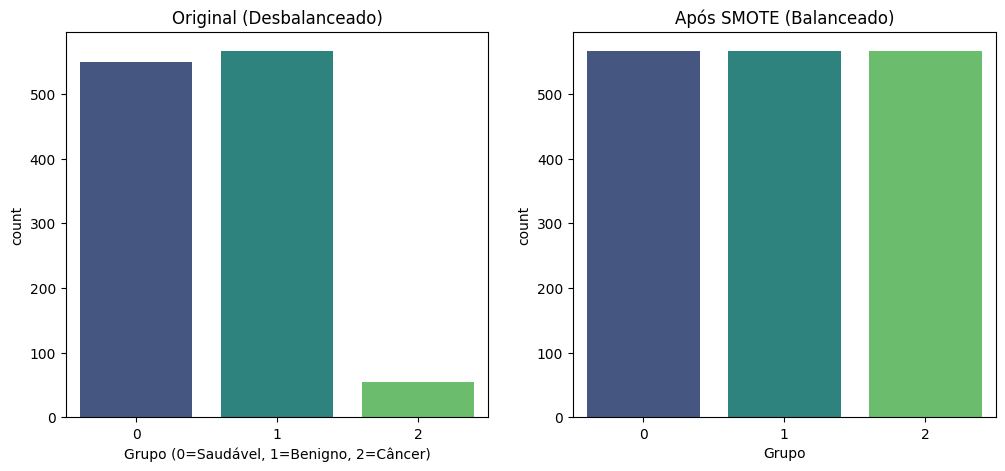

In [6]:
print("DISTRIBUIÇÃO ANTES DO BALANCEAMENTO:")
print(Counter(y_train))

# Criar o balanceador
smote = SMOTE(random_state=42)

# Aplicando no treino
X_train_bal, y_train_bal = smote.fit_resample(X_train_final, y_train)

print("\nDISTRIBUIÇÃO DEPOIS DO SMOTE:")
print(Counter(y_train_bal))

# Gráfico para visualizar o efeito
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title("Original (Desbalanceado)")
plt.xlabel("Grupo (0=Saudável, 1=Benigno, 2=Câncer)")

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_bal, palette='viridis')
plt.title("Após SMOTE (Balanceado)")
plt.xlabel("Grupo")

plt.show()

Criando CSV

In [7]:
# Salvar os conjuntos de treino balanceados e teste normalizados
X_train_bal.to_csv('X_train_pronto_SMOTE.csv', index=False)
y_train_bal.to_csv('y_train_pronto_SMOTE.csv', index=False)

X_test_final.to_csv('X_test_pronto_SMOTE.csv', index=False)
y_test.to_csv('y_test_pronto_SMOTE.csv', index=False)

print("💾 Arquivos salvos com sucesso!")

💾 Arquivos salvos com sucesso!
